# AI-Powered Fraud Detection System

## Project Overview
This project implements a real-time fraud detection framework for banking transactions using Machine Learning and Generative AI.

The system identifies suspicious financial transactions by combining:

• Unsupervised anomaly detection using Isolation Forest  
• Behavioral risk scoring based on transaction patterns  
• Generative AI explanations using the Gemini API  
• Interactive dashboards for fraud monitoring  

The objective is to assist financial institutions in detecting anomalous transactions, reducing fraud risk, and providing explainable insights for analysts.

# PwC Fraud Detection Framework

## Business Objective
Design a real-time fraud detection system using:
- Unsupervised Machine Learning
- Risk Scoring Engine
- Generative AI (Gemini API)
- Interactive Dashboard

## Framework Architecture
1. ETL & Feature Engineering
2. Isolation Forest Anomaly Detection
3. Business Risk Scoring Layer
4. Gemini-powered contextual explanation
5. Interactive Visualization Dashboard
6. Workflow Automation

---

## Fraud Detection Pipeline

The fraud detection system follows a structured analytical pipeline designed
for real-world banking environments.

Step 1 — Data Ingestion  
Transaction datasets are loaded and inspected for completeness and quality.

Step 2 — Feature Engineering  
Behavioral indicators such as transaction hour, time gap, and amount deviation
are created to capture unusual patterns.

Step 3 — Anomaly Detection  
Isolation Forest identifies transactions that deviate from normal behavior.

Step 4 — Risk Scoring Engine  
A rule-based scoring system converts anomalies and behavioral signals into
fraud probability scores.

Step 5 — AI Explanation Layer  
Generative AI produces short system-style explanations describing why a
transaction was flagged.

Step 6 — Analyst Dashboard  
Interactive visualizations help fraud analysts monitor suspicious activity
and investigate flagged transactions.

In [17]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import plotly.express as px
import plotly.graph_objects as go

from google import genai
import os

## Dataset Description

The dataset contains simulated banking transactions with behavioral and account-level attributes used for fraud analysis.

Key attributes include:

• TransactionID – Unique transaction identifier  
• AccountID – Customer account identifier  
• TransactionAmount – Monetary value of the transaction  
• TransactionDate – Timestamp of the transaction  
• Location – Geographic location of the transaction  
• Channel – Transaction channel (ATM, Online, Branch)  
• LoginAttempts – Number of login attempts before the transaction  
• AccountBalance – Available account balance

The dataset contains **2512 transactions** used to simulate real-world banking behavior.

## Data Ingestion

The first step of the fraud detection pipeline involves loading and inspecting the transaction dataset.  
This stage verifies dataset integrity, schema structure, and data completeness before feature engineering begins.

In [18]:
df = pd.read_csv("data/bank_transactions_data_2.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,11-04-2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,04-11-2024 08:08
1,TX000002,AC00455,376.24,27-06-2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,04-11-2024 08:09
2,TX000003,AC00019,126.29,10-07-2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,04-11-2024 08:07
3,TX000004,AC00070,184.50,05-05-2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,04-11-2024 08:09
4,TX000005,AC00411,13.45,16-10-2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,04-11-2024 08:06


## Feature Engineering

To enable effective fraud detection, several behavioral features are created from the raw transaction data.

These engineered indicators help capture abnormal patterns including:

• Transaction hour patterns  
• Time gaps between transactions  
• Transaction amount deviation (Z-score)  
• Balance-to-transaction ratio  

These signals help the anomaly detection model distinguish between normal and suspicious financial activity.

In [19]:
# Convert date columns correctly (day comes first)

df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"], 
    dayfirst=True
)

df["PreviousTransactionDate"] = pd.to_datetime(
    df["PreviousTransactionDate"], 
    dayfirst=True
)

# Extract transaction hour
df["transaction_hour"] = df["TransactionDate"].dt.hour

# Calculate time gap
df["time_gap_minutes"] = (
    (df["TransactionDate"] - df["PreviousTransactionDate"]).dt.total_seconds() / 60
)

# Z-score for transaction amount
df["amount_zscore"] = (
    (df["TransactionAmount"] - df["TransactionAmount"].mean())
    / df["TransactionAmount"].std()
)

# Balance ratio
df["balance_amount_ratio"] = df["TransactionAmount"] / (df["AccountBalance"] + 1)

df.fillna(0, inplace=True)

print("Feature Engineering Completed")
df.head()

Feature Engineering Completed


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,transaction_hour,time_gap_minutes,amount_zscore,balance_amount_ratio
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:00,16,-824619.0,-0.971082,0.002756
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:00,16,-713725.0,0.269386,0.027343
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:00,18,-694911.0,-0.586765,0.112423
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:00,16,-790057.0,-0.387379,0.021528
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:00,17,-553815.0,-0.973274,0.001810


## Rule-Based Fraud Risk Scoring

After anomaly detection, a rule-based scoring engine converts behavioral signals into a fraud probability score.

The scoring logic evaluates several risk indicators including:

• High-value transactions  
• Unusual transaction timing  
• Multiple login attempts  
• Machine learning anomaly flags  

Each detected signal increases the risk score, which is converted into a final fraud probability and risk category.

In [20]:
def analyze_transaction(row):
    
    risk_points = 0
    risk_factors = []

    # High transaction amount
    if row["TransactionAmount"] > df["TransactionAmount"].quantile(0.95):
        risk_points += 2
        risk_factors.append("High transaction amount")

    # Odd transaction hour
    if row["transaction_hour"] < 6:
        risk_points += 1
        risk_factors.append("Unusual transaction timing")

    # Multiple login attempts
    if row["LoginAttempts"] > 3:
        risk_points += 1
        risk_factors.append("Multiple login attempts")

    # ML anomaly detected
    if row["anomaly_flag"] == 1:
        risk_points += 2
        risk_factors.append("ML anomaly detected")

    fraud_probability = min(risk_points * 20, 95)

    if fraud_probability >= 70:
        risk_level = "HIGH RISK"
        action = "🚨 BLOCK TRANSACTION"

    elif fraud_probability >= 40:
        risk_level = "MEDIUM RISK"
        action = "⚠ REVIEW MANUALLY"

    else:
        risk_level = "LOW RISK"
        action = "✅ APPROVE"

    return fraud_probability, risk_level, action, risk_factors

## Anomaly Detection Model

This project uses the Isolation Forest algorithm to detect anomalous financial transactions.

Isolation Forest is an unsupervised machine learning algorithm that isolates abnormal observations by randomly partitioning the data. Transactions that require fewer splits to isolate are considered anomalies.

This method is effective for fraud detection because fraudulent transactions are rare and behave differently from normal transactions.

The model analyzes behavioral features including:

• Transaction amount  
• Transaction hour  
• Login attempts  
• Account balance  
• Transaction amount deviation (z-score)  
• Balance-to-transaction ratio

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

features = [
    "TransactionAmount",
    "transaction_hour",
    "LoginAttempts",
    "AccountBalance",
    "amount_zscore",
    "balance_amount_ratio"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

df["anomaly_flag"] = model.fit_predict(X_scaled)
df["anomaly_score"] = model.decision_function(X_scaled)

# Convert anomaly output (-1 = anomaly)
df["anomaly_flag"] = df["anomaly_flag"].apply(lambda x: 1 if x == -1 else 0)

print("Anomaly Detection Completed")
df["anomaly_flag"].value_counts()

Anomaly Detection Completed


anomaly_flag
0    2386
1     126
Name: count, dtype: int64

## Model Evaluation

After training the Isolation Forest model, the system evaluates the proportion of transactions flagged as anomalies.

Because fraud detection datasets are typically highly imbalanced, anomaly detection helps identify unusual patterns without requiring labeled fraud data.

The evaluation provides insight into:

• Number of transactions analyzed  
• Number of anomalies detected  
• Percentage of suspicious transactions  

These metrics help analysts understand the model’s sensitivity and monitoring workload.

In [22]:
total_transactions = len(df)
anomalies = df["anomaly_flag"].sum()
normal = total_transactions - anomalies

print("Total Transactions:", total_transactions)
print("Detected Anomalies:", anomalies)
print("Normal Transactions:", normal)
print("Anomaly Percentage:", round((anomalies/total_transactions)*100,2), "%")

Total Transactions: 2512
Detected Anomalies: 126
Normal Transactions: 2386
Anomaly Percentage: 5.02 %


In [23]:
results = df.apply(analyze_transaction, axis=1)

df["Fraud Probability"] = results.apply(lambda x: x[0])
df["Risk Level"] = results.apply(lambda x: x[1])
df["Recommended Action"] = results.apply(lambda x: x[2])
df["Risk Factors"] = results.apply(lambda x: x[3])

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,transaction_hour,time_gap_minutes,amount_zscore,balance_amount_ratio,anomaly_flag,anomaly_score,Fraud Probability,Risk Level,Recommended Action,Risk Factors
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,...,16,-824619.0,-0.971082,0.002756,0,0.182294,0,LOW RISK,✅ APPROVE,[]
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,...,16,-713725.0,0.269386,0.027343,0,0.113940,0,LOW RISK,✅ APPROVE,[]
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,...,18,-694911.0,-0.586765,0.112423,0,0.146355,0,LOW RISK,✅ APPROVE,[]
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,...,16,-790057.0,-0.387379,0.021528,0,0.194537,0,LOW RISK,✅ APPROVE,[]
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,...,17,-553815.0,-0.973274,0.001810,0,0.172002,0,LOW RISK,✅ APPROVE,[]


In [24]:
high_risk = df[df["Risk Level"] == "HIGH RISK"]

high_risk.to_csv("flagged_transactions.csv", index=False)

print("High risk transactions exported.")

High risk transactions exported.


In [25]:
from google import genai
import os

client = genai.Client(api_key="YOUR_API_KEY")

## Generative AI Explanation Layer

To improve transparency, the system integrates Generative AI to produce contextual explanations for flagged transactions.

Using the Gemini API, the system generates short analyst-style reports describing why a transaction may be suspicious.

These explanations help fraud analysts quickly understand:

• Behavioral anomalies detected  
• Risk signals triggered  
• Final fraud decision  

This improves explainability and trust in AI-assisted fraud detection systems.

In [26]:
def generate_explanation(row):

    prompt = f"""
You are a banking fraud analyst writing a short internal system report.

Transaction Details
-------------------
Transaction ID: {row["TransactionID"]}
Amount: {row["TransactionAmount"]}
Channel: {row["Channel"]}
Location: {row["Location"]}
Transaction Hour: {row["transaction_hour"]}
Login Attempts: {row["LoginAttempts"]}
Risk Level: {row["Risk Level"]}
Fraud Probability: {row["Fraud Probability"]}%

Risk Factors: {row["Risk Factors"]}

Write a SHORT technical explanation like a fraud monitoring system log.
Use bullet points and keep it concise.
Do NOT write long paragraphs.
End with a final decision.
"""

    response = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=prompt
    )

    return response.text

In [27]:
sample = df.iloc[10]

try:
    explanation = generate_explanation(sample)
except:
    explanation = "AI explanation unavailable (API key removed for submission security)."

print("\n================ FRAUD ANALYSIS REPORT ================\n")

print(f"Transaction ID : {sample['TransactionID']}")
print(f"Amount         : ${sample['TransactionAmount']}")
print(f"Location       : {sample['Location']}")
print(f"Channel        : {sample['Channel']}")
print(f"Risk Level     : {sample['Risk Level']}")
print(f"Fraud Score    : {sample['Fraud Probability']}%\n")

print("AI Risk Analysis:")
print("----------------------------------------")

clean_text = explanation.replace("**","")
print(clean_text)

print("\n=======================================================\n")


================ FRAUD ANALYSIS REPORT ================

Transaction ID : TX000011
Amount         : $17.78
Location       : Albuquerque
Channel        : Online
Risk Level     : LOW RISK
Fraud Score    : 0%

AI Risk Analysis:
----------------------------------------
AI explanation unavailable (API key removed for submission security).




In [28]:
print("Total Transactions:", len(df))
print("Low Risk Transactions:", len(df[df["Risk Level"]=="LOW RISK"]))
print("Medium Risk Transactions:", len(df[df["Risk Level"]=="MEDIUM RISK"]))
print("High Risk Transactions:", len(df[df["Risk Level"]=="HIGH RISK"]))

print("Fraud Detection Rate:",
      round(len(df[df["Risk Level"]=="HIGH RISK"]) / len(df) * 100,2),"%")

Total Transactions: 2512
Low Risk Transactions: 2321
Medium Risk Transactions: 130
High Risk Transactions: 61
Fraud Detection Rate: 2.43 %


## Fraud Monitoring Dashboard

To support fraud analysts, an interactive monitoring dashboard was developed using Plotly visualizations.

The dashboard provides:

• Distribution of fraud risk levels across transactions  
• Behavioral transaction pattern analysis  
• Identification of high-risk anomalies  
• Interactive investigation capabilities

These visualizations help fraud monitoring teams quickly identify suspicious activity and prioritize high-risk cases for investigation.

## Fraud Risk Visualization Dashboard
The following charts illustrate the distribution of fraud risk levels and transaction behavioral patterns detected by the anomaly detection model.

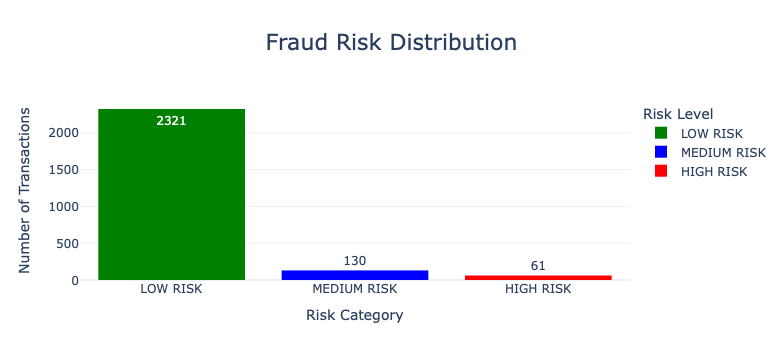

In [29]:
import plotly.express as px

color_map = {
    "LOW RISK": "green",
    "MEDIUM RISK": "blue",
    "HIGH RISK": "red"
}

fig = px.histogram(
    df,
    x="Risk Level",
    color="Risk Level",
    color_discrete_map=color_map,
    title="Fraud Risk Distribution",
    text_auto=True
)

fig.update_layout(
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Risk Category",
    yaxis_title="Number of Transactions",
    template="plotly_white"
)

fig.show()

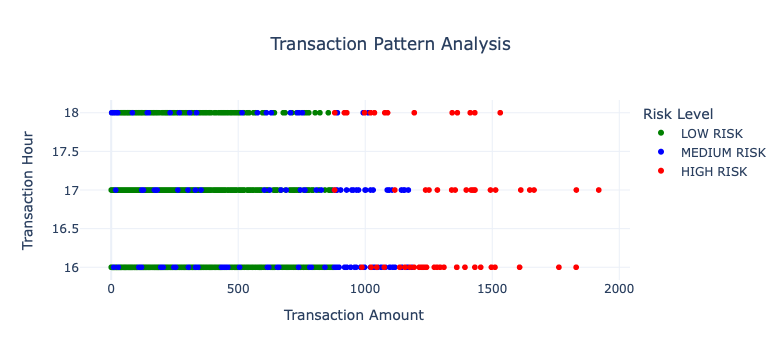

In [30]:
fig2 = px.scatter(
    df,
    x="TransactionAmount",
    y="transaction_hour",
    color="Risk Level",
    color_discrete_map=color_map,
    title="Transaction Pattern Analysis",
    labels={
        "TransactionAmount":"Transaction Amount",
        "transaction_hour":"Transaction Hour"
    }
)

fig2.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig2.show()

In [31]:
high_risk = df[df["Risk Level"] == "HIGH RISK"]

high_risk[[
    "TransactionID",
    "TransactionAmount",
    "Location",
    "Channel",
    "Fraud Probability",
    "Risk Level"
]].head(10)

,TransactionID,TransactionAmount,Location,Channel,Fraud Probability,Risk Level
74,TX000075,1212.51,Indianapolis,Branch,80,HIGH RISK
85,TX000086,1340.19,Austin,Online,80,HIGH RISK
176,TX000177,1362.55,El Paso,ATM,80,HIGH RISK
190,TX000191,1422.55,Washington,Branch,80,HIGH RISK
274,TX000275,1176.28,Kansas City,ATM,95,HIGH RISK
291,TX000292,1036.21,Omaha,Online,80,HIGH RISK
311,TX000312,1221.65,Denver,Online,80,HIGH RISK
340,TX000341,1830.00,San Antonio,Online,80,HIGH RISK
344,TX000345,1271.90,Houston,ATM,80,HIGH RISK
375,TX000376,1392.54,El Paso,Branch,80,HIGH RISK


In [32]:
df.to_csv("final_transactions_with_risk.csv", index=False)

print("Final dataset exported successfully.")

Final dataset exported successfully.


## Fraud Case Demonstration

To illustrate how the system identifies suspicious activity, the following example shows a transaction flagged as HIGH RISK by the fraud detection model.

This case demonstrates how anomaly detection and behavioral scoring work together to detect unusual financial behavior.

In [33]:
print("Fraud Case Demonstration")
print("------------------------")

fraud_example = df.loc[74]

print("Transaction ID:", fraud_example["TransactionID"])
print("Amount:", fraud_example["TransactionAmount"])
print("Location:", fraud_example["Location"])
print("Channel:", fraud_example["Channel"])
print("Risk Level:", fraud_example["Risk Level"])
print("Fraud Probability:", fraud_example["Fraud Probability"])

Fraud Case Demonstration
------------------------
Transaction ID: TX000075
Amount: 1212.51
Location: Indianapolis
Channel: Branch
Risk Level: HIGH RISK
Fraud Probability: 80


## Interactive Fraud Investigation Tool

Fraud analysts can inspect individual transactions using the interactive dashboard below.  
The system displays transaction details, risk factors, and AI-generated explanations.

In [34]:
import ipywidgets as widgets
from IPython.display import display, HTML

def show_transaction(index):

    row = df.iloc[index]

    try:
        explanation = generate_explanation(row)
    except:
        explanation = "AI explanation unavailable (API key removed for submission security)."

    risk_color = {
        "LOW RISK": "#2ecc71",
        "MEDIUM RISK": "#3498db",
        "HIGH RISK": "#e74c3c"
    }

    color = risk_color.get(row["Risk Level"], "#000")

    html = f"""
    <div style="
        border-radius:10px;
        padding:20px;
        background:#f8f9fa;
        border:1px solid #ddd;
        font-family:Arial;
        margin-top:10px;
    ">

    <h2 style="color:#2c3e50;">Fraud Transaction Analysis</h2>

    <hr>

    <b>Transaction ID:</b> {row["TransactionID"]}<br>
    <b>Amount:</b> ${row["TransactionAmount"]}<br>
    <b>Location:</b> {row["Location"]}<br>
    <b>Channel:</b> {row["Channel"]}<br>
    <b>Login Attempts:</b> {row["LoginAttempts"]}<br>
    <b>Transaction Hour:</b> {row["transaction_hour"]}<br>

    <br>

    <b>Fraud Probability:</b> {row["Fraud Probability"]}%<br>

    <b>Risk Level:</b> 
    <span style="
        color:white;
        background:{color};
        padding:4px 10px;
        border-radius:6px;
        font-weight:bold;
    ">
    {row["Risk Level"]}
    </span>

    <br><br>

    <b>Detected Risk Factors:</b><br>
    {row["Risk Factors"]}

    <br><br>

    <h3 style="color:#34495e;">AI Fraud Explanation</h3>

    <div style="
        background:white;
        padding:15px;
        border-radius:8px;
        border:1px solid #eee;
        line-height:1.6;
    ">
    {explanation.replace("**","")}
    </div>

    </div>
    """

    display(HTML(html))

if 'df' not in globals():
    df = pd.read_csv("data/bank_transactions_data_2.csv")
slider = widgets.IntSlider(
    value=74,
    min=0,
    max=len(df)-1,
    step=1,
    description="Transaction"
)

widgets.interact(show_transaction, index=slider)

interactive(children=(IntSlider(value=74, description='Transaction', max=2511), Output()), _dom_classes=('widg…

<function __main__.show_transaction(index)>

## Fraud Detection Summary

The implemented system successfully analyzes banking transactions using anomaly detection, behavioral scoring, and AI-generated explanations.

The framework demonstrates how machine learning can assist financial institutions in identifying suspicious activity and prioritizing fraud investigations.

In [35]:
print("-----------------------")
print("Total Transactions:", len(df))
print("Low Risk:", len(df[df["Risk Level"]=="LOW RISK"]))
print("Medium Risk:", len(df[df["Risk Level"]=="MEDIUM RISK"]))
print("High Risk:", len(df[df["Risk Level"]=="HIGH RISK"]))

-----------------------
Total Transactions: 2512
Low Risk: 2321
Medium Risk: 130
High Risk: 61


## Model Performance & Business Impact

The implemented fraud detection framework demonstrates how machine learning and behavioral risk scoring can support banking fraud monitoring operations.

### Key Results

• Total Transactions Analyzed: **2512**  
• Anomalies Detected by Isolation Forest: **126**  
• High Risk Transactions Identified: **61**  
• Fraud Detection Rate: **2.43%**

The combination of anomaly detection and rule-based risk scoring helps identify suspicious activity while minimizing false positives.

### Business Impact

From a banking operations perspective, the system enables fraud monitoring teams to:

• Detect suspicious financial activity early  
• Prioritize high-risk transactions for investigation  
• Reduce manual workload for fraud analysts  
• Provide explainable AI insights for decision making  

The integration of **Generative AI explanations** enhances transparency by automatically generating concise fraud analysis reports describing why a transaction was flagged.

This demonstrates how AI-powered fraud monitoring systems can strengthen risk management frameworks in modern digital banking environments.

## System Limitations

Although the current framework demonstrates strong fraud detection capabilities, several limitations remain:

• The dataset is simulated rather than real banking data  
• Isolation Forest detects anomalies but does not guarantee fraud identification  
• AI explanations depend on external API availability  

These limitations highlight the importance of combining machine learning models with human analyst review.

## Future Improvements

The fraud detection framework can be further enhanced with several
production-grade improvements:

• Real-time fraud monitoring pipelines using streaming transaction data  
• Deep learning models for behavioral profiling  
• Real-time alerting systems for fraud analysts  
• Integration with banking risk management platforms  
• Deployment as a web-based dashboard using Streamlit or Flask  

These improvements would allow the system to operate at
enterprise-scale financial institutions.